<a href="https://colab.research.google.com/github/zeqkik/mdc_lambda_projeto_final/blob/main/05_efficientnetv2b0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import pandas as pd
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report, balanced_accuracy_score, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout, Input

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
from types import NoneType

def predict_and_evaluate(model, features, labels, threeshold = 0.5):

  pred_proba = model.predict(features)
  pred_positive = pred_proba[:, 1]
  pred = np.where(pred_positive > threeshold, 1, 0)
  if type(labels) != NoneType:
    bal_acc = balanced_accuracy_score(labels, pred)

    print('=='*10)
    print(f'Balanced Accuracy: {bal_acc}')
    print('=='*10)

    report = classification_report(labels, pred, zero_division=0)
    print(report)
    plot_confusion_matrix(labels, pred, ['benigna', 'maligna'], 2)


    return pred_proba, pred, bal_acc, report
  else:
    return pred_proba, pred

In [4]:
def plot_roc_curve(true: np.ndarray, pred: np.ndarray):
    prob_positive = pred[:, 1]

    fpr, tpr, thresholds = roc_curve(true, prob_positive)
    roc_auc = auc(fpr, tpr)

    j_scores = tpr - fpr
    j_index = np.argmax(j_scores)

    optimal_threshold = thresholds[j_index]
    plt.figure(figsize=(8, 6))

    # Curva do Modelo
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Curva ROC (AUC = {roc_auc:.4f})')

    # Linha de classificação aleatória
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatório')

    # Ponto do threshold ideal
    plt.plot(fpr[j_index], tpr[j_index], 'ro', markersize=8,
             label=f'Threshold Ideal ({optimal_threshold:.4f})')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
    plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)')
    plt.title('Curva ROC e Threshold Ótimo para Classificador de Melanoma')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    return optimal_threshold, roc_auc

In [5]:
IMAGE_SIZE = (224, 224)

def load_and_preprocess(file_path, label):
    """
    Função para carregar a aplicar pré processamento básico em uma imagem.
    Transformação da imagem em tensor e redimensionamento.
    """
    image_binary = tf.io.read_file(file_path)
    image_tf = tf.image.decode_jpeg(image_binary, channels=3)
    image = tf.image.resize(image_tf, IMAGE_SIZE)

    # EfficientNet espera pixels entre [0, 255], então APENAS converta para float
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.efficientnet.preprocess_input(image)

    return image, label

In [6]:
def load_and_preprocess_test(file_path):
    """
    Função para carregar a aplicar pré processamento básico em uma imagem.
    Transformação da imagem em tensor e redimensionamento.
    """
    image_binary = tf.io.read_file(file_path)
    image_tf = tf.image.decode_jpeg(image_binary, channels=3)
    image = tf.image.resize(image_tf, IMAGE_SIZE)

    # EfficientNet espera pixels entre [0, 255], então APENAS converta para float
    image = tf.cast(image, tf.float32)
    # Normalização específica do EfficientNet
    image = tf.keras.applications.efficientnet.preprocess_input(image)

    return image

In [7]:

def augment_data(image, label):
    """
    Função que aplica transformações aleatórias (Data Augmentation) na imagem.
    """
    # Flips esquerda direita, cima baixo
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)

    # Rotações de 90º
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)

    # Redimensionamento(Zoom-in 256x256 + Corte aleatório)
    image = tf.image.resize(image, [256, 256]) # Um leve zoom in
    image = tf.image.random_crop(image, size=[224, 224, 3])


    # Transformações de Cor
    image = tf.image.random_brightness(image, max_delta=0.1) # +/- 10%
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2) # +/- 20%
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2) # Saturação da cor

    # Manutenção de valores em limite válido
    image = tf.clip_by_value(image, 0.0, 255.0)

    return image, label


In [8]:
def predict_and_evaluate_binary(model, features, labels, threeshold = 0.5):

  pred_proba = model.predict(features)
  pred_positive = pred_proba[:]
  pred = np.where(pred_positive > threeshold, 1, 0)
  if type(labels) != NoneType:
    bal_acc = balanced_accuracy_score(labels, pred)

    print('=='*10)
    print(f'Balanced Accuracy: {bal_acc}')
    print('=='*10)

    report = classification_report(labels, pred, zero_division=0)
    print(report)
    plot_confusion_matrix(labels, pred, ['benigna', 'maligna'], 2)


    return pred_proba, pred, bal_acc, report
  else:
    return pred_proba, pred

In [9]:
def plot_roc_curve_binary(true: np.ndarray, pred: np.ndarray):
    prob_positive = pred[:]

    fpr, tpr, thresholds = roc_curve(true, prob_positive)
    roc_auc = auc(fpr, tpr)

    j_scores = tpr - fpr
    j_index = np.argmax(j_scores)

    optimal_threshold = thresholds[j_index]
    plt.figure(figsize=(8, 6))

    # Curva do Modelo
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Curva ROC (AUC = {roc_auc:.4f})')

    # Linha de classificação aleatória
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatório')

    # Ponto do threshold ideal
    plt.plot(fpr[j_index], tpr[j_index], 'ro', markersize=8,
             label=f'Threshold Ideal ({optimal_threshold:.4f})')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
    plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)')
    plt.title('Curva ROC e Threshold Ótimo para Classificador de Melanoma')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    return optimal_threshold, roc_auc

In [13]:
BATCH_SIZE = 128
BASE_DIR = '/content/drive/MyDrive/MDC_data/images/'

In [14]:
# Carregamento o dataframe de rótulos e criação do conjunto de dados como
# Dataset para obter performance otimizada de processamento

train_info = pd.read_csv("/content/drive/MyDrive/MDC_data/train.csv")

train_file_paths = [os.path.join(BASE_DIR, f'{img_path}') for img_path in train_info['path']]

y_train = train_info['target'].values

train_path_ds = tf.data.Dataset.from_tensor_slices((tf.constant(train_file_paths), tf.constant(y_train)))

train_images_ds = train_path_ds.map(load_and_preprocess,
                       num_parallel_calls=tf.data.AUTOTUNE)

train_ds_augmented = train_images_ds.shuffle(buffer_size=1024).map(
                    augment_data, # <--- Usando a nova função completa
                    num_parallel_calls=tf.data.AUTOTUNE
)

train_batches = train_ds_augmented.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [15]:
val_info = pd.read_csv("/content/drive/MyDrive/MDC_data/val.csv")

val_file_paths = [os.path.join(BASE_DIR, f'{img_path}') for img_path in val_info['path']]

y_val = val_info['target'].values

val_path_ds = tf.data.Dataset.from_tensor_slices((tf.constant(val_file_paths), tf.constant(y_val)))
val_images_ds = val_path_ds.map(load_and_preprocess,
                       num_parallel_calls=tf.data.AUTOTUNE)

val_batches = val_images_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [16]:
def plot_confusion_matrix(y_true, y_pred, class_names, NUM_CLASSES=4):
  cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES))).astype("float")
  cm = cm / cm.sum(axis=1, keepdims=True)

  plt.figure(figsize=(6,5))
  sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        cbar=True,
        linewidths=.5,
        linecolor='black'
    )

  plt.title("Matriz de Confusão Normalizada")
  ticks = np.arange(NUM_CLASSES)
  plt.xticks(ticks + 0.5, class_names, rotation=45, ha="right")
  plt.yticks(ticks + 0.5, class_names, rotation=0)
  plt.ylabel("Verdadeiro")
  plt.xlabel("Predito")
  plt.tight_layout()
  plt.show()

In [17]:
classes = np.unique(y_train)


weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

In [18]:
# base_model = tf.keras.applications.ResNet50(weights = 'imagenet', include_top = False, input_shape = (224, 224, 3))
base_model = tf.keras.applications.EfficientNetV2B0(weights ='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. CONGELAR completamente a base (Feature Extraction puro)
base_model.trainable = False

# Congelamento de todas camadas
#for layer in model.layers:
#    layer.trainable = False
# #Congelamento de n camadas
#for layer in base_model.layers[:-40]:
#    layer.trainable = False

model = tf.keras.Sequential([base_model,
                              tf.keras.layers.GlobalAveragePooling2D(),
                              Dropout(rate=0.3),
                              Dense(2, activation = 'softmax')])

input_shape = (None, 224, 224, 3)
model.build(input_shape=input_shape)
model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,921,874 (22.59 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [ ]:
import keras

#SGD
sgd = tf.keras.optimizers.SGD(learning_rate = 0.001, momentum = 0.9, decay = 0.001)

#Adam
learning_rate = 1e-3 # Uso de baixa taxa de aprendizado
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

#Early stopping
early = tf.keras.callbacks.EarlyStopping (monitor = 'val_loss', patience = 5, restore_best_weights = True)
f1_score = keras.metrics.F1Score(average = 'macro')

# Compila o modelo (assumindo que 'frozen_model' está definido).
model.compile(loss = 'sparse_categorical_crossentropy', optimizer = optimizer, metrics=['accuracy'])


In [ ]:
n_epochs = 10
history_a = model.fit(train_batches,
          epochs = n_epochs,
          class_weight = class_weights,
          validation_data = val_batches,
          callbacks=[early])


Epoch 1/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 141s 140ms/step - accuracy: 0.8650 - loss: 0.3091 - val_accuracy: 0.8144 - val_loss: 0.4352
Epoch 2/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.8827 - loss: 0.2662 - val_accuracy: 0.8388 - val_loss: 0.4144
Epoch 3/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 29s 45ms/step - accuracy: 0.9031 - loss: 0.2357 - val_accuracy: 0.8696 - val_loss: 0.3390
Epoch 4/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 29s 45ms/step - accuracy: 0.9130 - loss: 0.2146 - val_accuracy: 0.8544 - val_loss: 0.4246
Epoch 5/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.9281 - loss: 0.1774 - val_accuracy: 0.8736 - val_loss: 0.4169
Epoch 6/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.9373 - loss: 0.1599 - val_accuracy: 0.8576 - val_loss: 0.4123
Epoch 7/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.9386 - loss: 0.1515 - val_accuracy: 0.8792 - val_loss: 0.3891
Epoch 8/10
636/636 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.9431 - loss: 0.1404 

In [ ]:
base_model.trainable = True

#Adam
learning_rate = 1e-4 # Uso de baixa taxa de aprendizado
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

#Early stopping
early = tf.keras.callbacks.EarlyStopping (monitor = 'val_loss', patience = 5, restore_best_weights = True)
f1_score = keras.metrics.F1Score(average = 'macro')

# Compila o modelo (assumindo que 'frozen_model' está definido).
model.compile(loss = 'sparse_categorical_crossentropy', optimizer = optimizer, metrics=['accuracy'])


In [ ]:
# Treinamento
history_b = model.fit(
    train_batches,
    class_weight = class_weights,
    epochs=40,
    validation_data=val_batches,
    callbacks=[early]
)

Epoch 1/40
636/636 ━━━━━━━━━━━━━━━━━━━━ 140s 141ms/step - accuracy: 0.9297 - loss: 0.1749 - val_accuracy: 0.8836 - val_loss: 0.3178
Epoch 2/40
636/636 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.9490 - loss: 0.1231 - val_accuracy: 0.8864 - val_loss: 0.3232
Epoch 3/40
636/636 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.9590 - loss: 0.1083 - val_accuracy: 0.8924 - val_loss: 0.3319
Epoch 4/40
636/636 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.9694 - loss: 0.0846 - val_accuracy: 0.8924 - val_loss: 0.3356
Epoch 5/40
636/636 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.9714 - loss: 0.0733 - val_accuracy: 0.8960 - val_loss: 0.3452
Epoch 6/40
636/636 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.9768 - loss: 0.0679 - val_accuracy: 0.8952 - val_loss: 0.3658


79/79 ━━━━━━━━━━━━━━━━━━━━ 32s 196ms/step
Balanced Accuracy: 0.8394281541399843
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      2070
           1       0.63      0.77      0.70       430

    accuracy                           0.88      2500
   macro avg       0.79      0.84      0.81      2500
weighted avg       0.90      0.88      0.89      2500



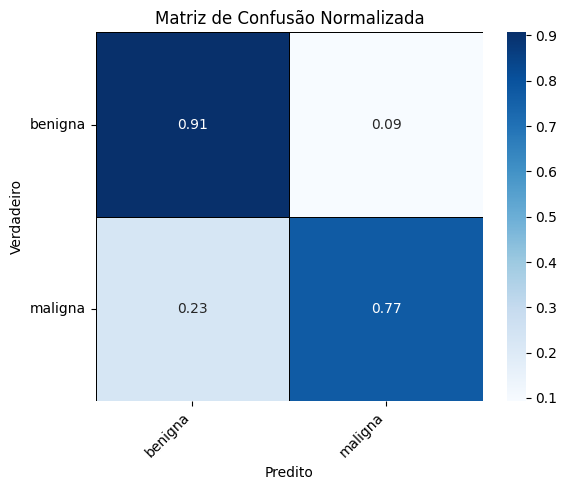

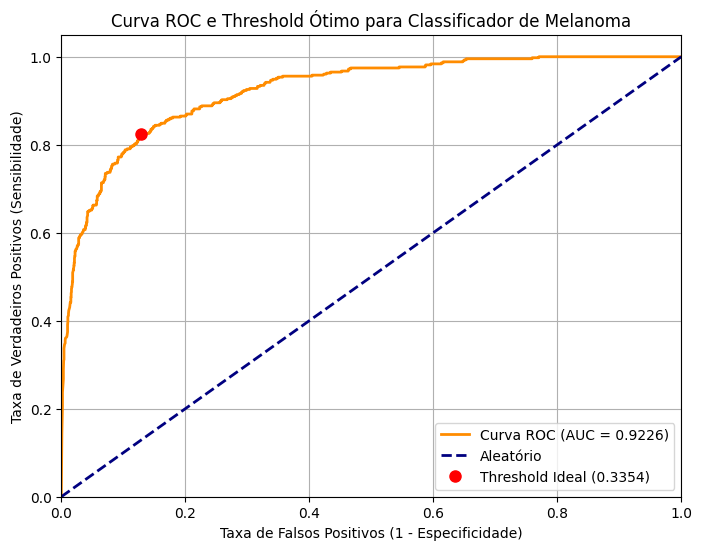

In [ ]:
val_pred_proba, val_pred, val_bal_acc, val_report = predict_and_evaluate(model, val_batches, y_val)
optimal_threshold, roc_auc = plot_roc_curve(y_val, val_pred_proba)

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step
Balanced Accuracy: 0.8459723626558814
              precision    recall  f1-score   support

           0       0.96      0.87      0.91      2070
           1       0.57      0.82      0.67       430

    accuracy                           0.86      2500
   macro avg       0.76      0.85      0.79      2500
weighted avg       0.89      0.86      0.87      2500



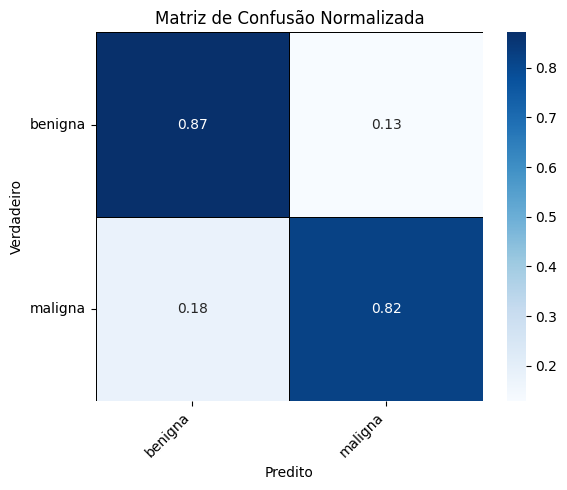

In [ ]:
val_pred_proba, val_pred, val_bal_acc, val_report = predict_and_evaluate(model, val_batches, y_val, optimal_threshold)

Iniciando TTA (4 visualizações por imagem)...


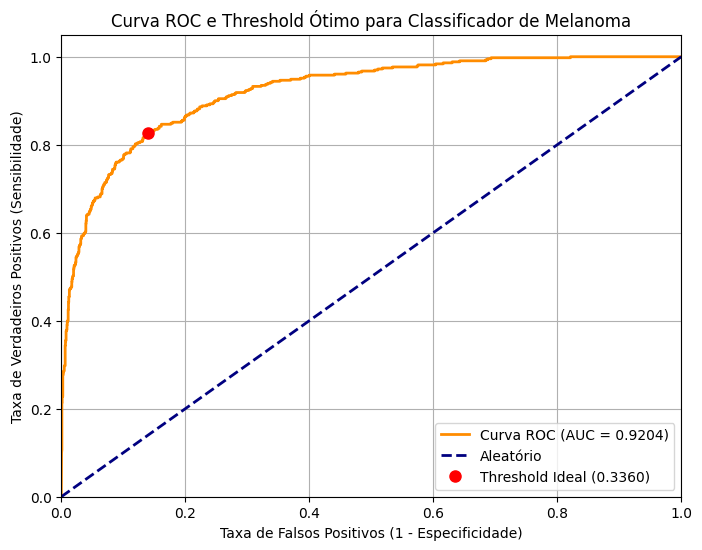


--- Resultado Final (Treino Robusto + TTA) ---
              precision    recall  f1-score   support

           0       0.96      0.86      0.91      2070
           1       0.55      0.82      0.66       430

    accuracy                           0.85      2500
   macro avg       0.76      0.84      0.78      2500
weighted avg       0.89      0.85      0.86      2500

Balanced Accuracy Final: 0.84206


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, balanced_accuracy_score

def predict_with_tta_geometry(model, dataset, steps):
    """
    Realiza predição com TTA focado em geometria:
    Original + Flip H + Flip V + Rotação 90.
    """
    print("Iniciando TTA (4 visualizações por imagem)...")

    final_probs = []
    true_labels = []

    # Itera sobre o dataset de validação (IMPORTANTE: Dataset não deve ter shuffle!)
    for images, labels in dataset.take(steps):
        # Acumulador para somar as probabilidades das 4 transformações
        # Shape: (batch_size, 2) pois sua saída é softmax de 2 classes
        batch_sum = np.zeros((images.shape[0], 2))

        # 1. Original
        batch_sum += model.predict(images, verbose=0)

        # 2. Flip Horizontal (Esquerda-Direita)
        batch_sum += model.predict(tf.image.flip_left_right(images), verbose=0)

        # 3. Flip Vertical (Cima-Baixo)
        batch_sum += model.predict(tf.image.flip_up_down(images), verbose=0)

        # 4. Rotação de 90 graus
        batch_sum += model.predict(tf.image.rot90(images, k=1), verbose=0)

        # Média simples
        batch_avg = batch_sum / 4.0

        final_probs.extend(batch_avg)
        true_labels.extend(labels.numpy())

    return np.array(final_probs), np.array(true_labels)

# ==========================================================
# EXECUÇÃO DA AVALIAÇÃO
# ==========================================================

# 1. Garantir dataset de validação limpo (sem augmentation, ordem sequencial)
# Recarregue se necessário para garantir que não tem shuffle
val_ds_clean = tf.data.Dataset.from_tensor_slices((val_file_paths, y_val))
val_ds_clean = val_ds_clean.map(load_and_preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 2. Rodar TTA
probs_tta, labels_tta = predict_with_tta_geometry(model, val_ds_clean, steps=len(val_ds_clean))

# 3. Extrair probabilidade da classe positiva (1 - Melanoma)
# Como é softmax, a coluna 0 é benigno, coluna 1 é maligno
probs_maligno = probs_tta[:, 1]

# 4. Calcular Threshold Ótimo e Métricas
optimal_threshold, roc_auc = plot_roc_curve_binary(labels_tta, probs_maligno) # Use sua função existente

print(f"\n--- Resultado Final (Treino Robusto + TTA) ---")
pred_final = np.where(probs_maligno > optimal_threshold, 1, 0)

print(classification_report(labels_tta, pred_final))
bal_acc = balanced_accuracy_score(labels_tta, pred_final)

print("="*40)
print(f"Balanced Accuracy Final: {bal_acc:.5f}")
print("="*40)

In [ ]:
import os
import glob
import pandas as pd
import tensorflow as tf
from datetime import datetime

# Diretório das imagens de teste
TEST_DIR = BASE_DIR + '/images/test/'
SAVE_DIR = os.path.join(os.path.dirname(BASE_DIR.rstrip('/')), 'effnetv2b0_models_submissions')

# Listar todos os arquivos de imagem no diretório
test_file_paths = sorted(glob.glob(os.path.join(TEST_DIR, '*.jpg')))

# Criar a lista de IDs para a submissão ('images/test/NOME_DO_ARQUIVO.jpg')
submission_ids = [f"images/test/{os.path.basename(path)}" for path in test_file_paths]

# Organizar os batches de teste
test_path_ds = tf.data.Dataset.from_tensor_slices(test_file_paths)
test_images_ds = test_path_ds.map(load_and_preprocess_test, num_parallel_calls=tf.data.AUTOTUNE)
test_batches = test_images_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Usar a funcao para retornar as probabilidades e as predições
test_proba, test_pred = predict_and_evaluate(model, test_batches, None, optimal_threshold)

# Colocar predições em um df com os ids ('images/test/NOME_DO_ARQUIVO.jpg')
submission_df = pd.DataFrame({
    'ID': submission_ids,
    'TARGET': test_pred
})

# Salvar o modelo e o arquivo de submissão para avaliar o conjunto de teste
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

submission_filename = f'{timestamp}_effnetv2b0_submission.csv'
model_filename = f'{timestamp}_effnetv2b0_model.keras'

submission_df.to_csv(os.path.join(SAVE_DIR, submission_filename), index=False)
model.save(os.path.join(SAVE_DIR, model_filename))
print("Modelo e Submissão Salvos")

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step
Modelo e Submissão Salvos


In [19]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight

# Configurações
N_FOLDS = 5
BATCH_SIZE = 32 # Ajuste conforme sua VRAM
EPOCHS = 40
IMG_SIZE = (224, 224)
SAVE_DIR = "/content/drive/MyDrive/MDC_data/models_kfold"
os.makedirs(SAVE_DIR, exist_ok=True)


def get_compiled_model():
    base = tf.keras.applications.EfficientNetV2B0(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
    base.trainable = True

    model = tf.keras.Sequential([
        base,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(2, activation='softmax')
    ])

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(1e-4),
        metrics=['accuracy']
    )
    return model


In [21]:

# 2. Preparação dos Dados
train_info = pd.read_csv("/content/drive/MyDrive/MDC_data/train.csv")
X_paths = np.array([os.path.join(BASE_DIR, p) for p in train_info['path']])
y_labels = train_info['target'].values

# 3. Loop K-Fold
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_histories = [] # Armazena métricas de cada fold

df_train = pd.read_csv("/content/drive/MyDrive/MDC_data/train.csv")
df_val = pd.read_csv("/content/drive/MyDrive/MDC_data/val.csv")

full_df = pd.concat([df_train, df_val], ignore_index=True)

# 3. Criar os arrays a partir desse conjunto completo
X_paths = np.array([os.path.join(BASE_DIR, p) for p in full_df['path']])
y_labels = full_df['target'].values


In [24]:
print(f"Iniciando treinamento K-Fold ({N_FOLDS} folds)...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_paths, y_labels)):
    print(f"\n--- Fold {fold+1}/{N_FOLDS} ---")
    tf.keras.backend.clear_session() # Limpa memória

    # Datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_paths[train_idx], y_labels[train_idx]))
    val_ds = tf.data.Dataset.from_tensor_slices((X_paths[val_idx], y_labels[val_idx]))

    # Pipeline
    train_ds = train_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    train_ds = train_ds.map(augment_data, num_parallel_calls=tf.data.AUTOTUNE)
    train_ds = train_ds.shuffle(1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    val_ds = val_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # Treinamento
    model = get_compiled_model()
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(f"{SAVE_DIR}/model_fold_{fold+1}.keras", save_best_only=True)
    ]

    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        validation_data=val_ds,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )

    fold_histories.append(history.history)

print("\nK-Fold concluído. Métricas armazenadas em 'fold_histories'.")

Iniciando treinamento K-Fold (5 folds)...

--- Fold 1/5 ---
Epoch 1/40
571/571 ━━━━━━━━━━━━━━━━━━━━ 1025s 1s/step - accuracy: 0.6384 - loss: 0.5844 - val_accuracy: 0.7876 - val_loss: 0.4552
Epoch 2/40
571/571 ━━━━━━━━━━━━━━━━━━━━ 39s 65ms/step - accuracy: 0.7688 - loss: 0.4583 - val_accuracy: 0.8042 - val_loss: 0.3972
Epoch 3/40
571/571 ━━━━━━━━━━━━━━━━━━━━ 39s 65ms/step - accuracy: 0.7920 - loss: 0.4210 - val_accuracy: 0.8113 - val_loss: 0.4016
Epoch 4/40
571/571 ━━━━━━━━━━━━━━━━━━━━ 39s 66ms/step - accuracy: 0.8176 - loss: 0.3837 - val_accuracy: 0.8577 - val_loss: 0.3359
Epoch 5/40
571/571 ━━━━━━━━━━━━━━━━━━━━ 39s 65ms/step - accuracy: 0.8213 - loss: 0.3599 - val_accuracy: 0.8305 - val_loss: 0.3709
Epoch 6/40
571/571 ━━━━━━━━━━━━━━━━━━━━ 38s 64ms/step - accuracy: 0.8331 - loss: 0.3324 - val_accuracy: 0.8183 - val_loss: 0.3871
Epoch 7/40
571/571 ━━━━━━━━━━━━━━━━━━━━ 38s 63ms/step - accuracy: 0.8479 - loss: 0.3148 - val_accuracy: 0.8334 - val_loss: 0.3662
Epoch 8/40
571/571 ━━━━━━━━━━━

In [25]:
print(f"Dataset Total Reconstruído: {len(full_df)} imagens (Treino + Val Originais)")

# Cria os arrays a partir do Dataset Completo
X_paths = np.array([os.path.join(BASE_DIR, p) for p in full_df['path']])
y_labels = full_df['target'].values

# Arrays globais para armazenar as predições OOF de todos os folds
oof_preds_global = np.zeros(len(X_paths))
oof_targets_global = np.zeros(len(X_paths))

# Configuração do K-Fold (Deve ter o mesmo SEED do treinamento)
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# Lista para resumo tabular
fold_metrics_summary = []

Dataset Total Reconstruído: 22831 imagens (Treino + Val Originais)


In [26]:
# Arrays globais para armazenar as predições OOF de todos os folds
oof_preds_global = np.zeros(len(X_paths))
oof_targets_global = np.zeros(len(X_paths))

# Configuração do K-Fold (Deve ter o mesmo SEED do treinamento)
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# Lista para resumo tabular
fold_metrics_summary = []

In [28]:
import keras
for fold, (train_idx, val_idx) in enumerate(skf.split(X_paths, y_labels)):
    fold_num = fold + 1
    print(f"\n{'='*20} AVALIANDO FOLD {fold_num}/{N_FOLDS} {'='*20}")

    # 1. Carregar Modelo do Fold correspondente
    model_path = os.path.join(SAVE_DIR, f"model_fold_{fold_num}.keras")
    if not os.path.exists(model_path):
        print(f"Modelo não encontrado: {model_path}")
        continue

    model = keras.models.load_model(model_path)

    # 2. Isolar dados de validação deste fold
    # Como estamos usando o full_df, val_idx aponta para os dados corretos
    X_val_fold = X_paths[val_idx]
    y_val_fold = y_labels[val_idx]

    # Pipeline de Validação (Sem Shuffle)
    val_ds = tf.data.Dataset.from_tensor_slices((X_val_fold, y_val_fold))
    val_ds = val_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # 3. Predição
    val_probs = model.predict(val_ds, verbose=0)
    prob_maligno = val_probs[:, 1] # Coluna 1

    # Armazenar no array Global (OOF)
    oof_preds_global[val_idx] = prob_maligno
    oof_targets_global[val_idx] = y_val_fold

    # 4. Métricas LOCAIS do Fold (Threshold Otimizado Local)
    fpr, tpr, thresholds = roc_curve(y_val_fold, prob_maligno)
    best_thresh_fold = thresholds[np.argmax(tpr - fpr)]

    preds_fold = np.where(prob_maligno > best_thresh_fold, 1, 0)
    bal_acc = balanced_accuracy_score(y_val_fold, preds_fold)
    cm = confusion_matrix(y_val_fold, preds_fold)

    # Exibir Métricas do Fold
    print(f"Threshold Ideal: {best_thresh_fold:.4f}")
    print(f"Balanced Accuracy: {bal_acc:.5f}")
    print("Matriz de Confusão:")
    print(pd.DataFrame(cm, index=['Real 0', 'Real 1'], columns=['Pred 0', 'Pred 1']))

    fold_metrics_summary.append({
        'Fold': fold_num,
        'Threshold': best_thresh_fold,
        'Bal_Acc': bal_acc,
        'TP': cm[1,1], 'TN': cm[0,0], 'FP': cm[0,1], 'FN': cm[1,0]
    })

    tf.keras.backend.clear_session()


==================== AVALIANDO FOLD 1/5 ====================
Threshold Ideal: 0.3637
Balanced Accuracy: 0.80913
Matriz de Confusão:
        Pred 0  Pred 1
Real 0    3000     757
Real 1     146     664

==================== AVALIANDO FOLD 2/5 ====================
Threshold Ideal: 0.2025
Balanced Accuracy: 0.82369
Matriz de Confusão:
        Pred 0  Pred 1
Real 0    3039     717
Real 1     131     679

==================== AVALIANDO FOLD 3/5 ====================
Threshold Ideal: 0.4165
Balanced Accuracy: 0.82281
Matriz de Confusão:
        Pred 0  Pred 1
Real 0    3204     552
Real 1     168     642

==================== AVALIANDO FOLD 4/5 ====================
Threshold Ideal: 0.3186
Balanced Accuracy: 0.83951
Matriz de Confusão:
        Pred 0  Pred 1
Real 0    3181     575
Real 1     136     674

==================== AVALIANDO FOLD 5/5 ====================
Threshold Ideal: 0.3451
Balanced Accuracy: 0.82871
Matriz de Confusão:
        Pred 0  Pred 1
Real 0    3239     517
Real 1     16

In [30]:
print(f"\n{'='*20} ANÁLISE CONSOLIDADA {'='*20}")

# 1. Resumo por Fold
summary_df = pd.DataFrame(fold_metrics_summary)
print("\nDesempenho por Fold:")
print(summary_df[['Fold', 'Bal_Acc', 'Threshold', 'FP', 'FN']])
print(f"Média Bal Acc: {summary_df['Bal_Acc'].mean():.4f} (std: {summary_df['Bal_Acc'].std():.4f})")

# 2. Cálculo do Threshold Global (Usando todas as previsões OOF juntas)
fpr, tpr, thresholds = roc_curve(oof_targets_global, oof_preds_global)
optimal_threshold_global = thresholds[np.argmax(tpr - fpr)]

# 3. Métricas Globais Finais
global_preds = np.where(oof_preds_global > optimal_threshold_global, 1, 0)
global_bal_acc = balanced_accuracy_score(oof_targets_global, global_preds)
global_cm = confusion_matrix(oof_targets_global, global_preds)

print("\n--- PERFORMANCE GLOBAL DO ENSEMBLE (CROSS-VALIDATION) ---")
print(f"Threshold Otimizado Global: {optimal_threshold_global:.5f}")
print(f"Balanced Accuracy Global: {global_bal_acc:.5f}")
print("\nMatriz de Confusão Global (OOF):")
print(pd.DataFrame(global_cm, index=['Real Benigno', 'Real Maligno'], columns=['Pred Benigno', 'Pred Maligno']))


==================== ANÁLISE CONSOLIDADA ====================

Desempenho por Fold:
   Fold   Bal_Acc  Threshold   FP   FN
0     1  0.809131   0.363739  757  146
1     2  0.823689   0.202510  717  131
2     3  0.822814   0.416462  552  168
3     4  0.839505   0.318556  575  136
4     5  0.828708   0.345116  517  166
Média Bal Acc: 0.8248 (std: 0.0110)

--- PERFORMANCE GLOBAL DO ENSEMBLE (CROSS-VALIDATION) ---
Threshold Otimizado Global: 0.34006
Balanced Accuracy Global: 0.82362

Matriz de Confusão Global (OOF):
              Pred Benigno  Pred Maligno
Real Benigno         15680          3101
Real Maligno           760          3290


In [32]:
import glob

In [33]:
print(f"Usando Threshold Otimizado Global: {optimal_threshold_global:.5f}")

# Listar arquivos de teste (Ordenado é importante para manter consistência)
test_file_paths = sorted(glob.glob(os.path.join(BASE_DIR, 'images/test/*.jpg')))

# Pipeline de Teste (Simples, apenas Resize e Rescale)
# Nota: Se quiser usar TTA aqui para ganhar +1%, avise que eu passo a função adaptada
test_ds = tf.data.Dataset.from_tensor_slices(test_file_paths)
test_ds = test_ds.map(load_and_preprocess_test, num_parallel_calls=tf.data.AUTOTUNE)
test_batches = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Total de imagens de teste: {len(test_file_paths)}")

Usando Threshold Otimizado Global: 0.34006
Total de imagens de teste: 2500


In [35]:
print(f"\n--- Iniciando Predição Ensemble ({N_FOLDS} Folds) ---")

# Acumulador para somar as probabilidades de todos os modelos
# Shape: (N_Imagens, 2_Classes)
ensemble_probs_sum = np.zeros((len(test_file_paths), 2))

for fold in range(1, N_FOLDS + 1):
    model_path = os.path.join(SAVE_DIR, f"model_fold_{fold}.keras")
    print(f"-> Carregando e prevendo: {model_path} ...", end=" ")

    if not os.path.exists(model_path):
        print("Arquivo não encontrado!")
        continue

    # Carregar modelo
    model = keras.models.load_model(model_path)

    # Prever (Standard, sem TTA para ser mais rápido)
    probs = model.predict(test_batches, verbose=0)

    # Somar ao acumulador global
    ensemble_probs_sum += probs

    print("Concluído.")

    # Limpar memória da GPU/RAM
    tf.keras.backend.clear_session()


--- Iniciando Predição Ensemble (5 Folds) ---
-> Carregando e prevendo: /content/drive/MyDrive/MDC_data/models_kfold/model_fold_1.keras ... Concluído.
-> Carregando e prevendo: /content/drive/MyDrive/MDC_data/models_kfold/model_fold_2.keras ... Concluído.
-> Carregando e prevendo: /content/drive/MyDrive/MDC_data/models_kfold/model_fold_3.keras ... Concluído.
-> Carregando e prevendo: /content/drive/MyDrive/MDC_data/models_kfold/model_fold_4.keras ... Concluído.
-> Carregando e prevendo: /content/drive/MyDrive/MDC_data/models_kfold/model_fold_5.keras ... Concluído.


In [36]:
print("\n--- Processando Resultados Finais ---")

# 1. Média das Probabilidades (Soft Voting)
avg_probs = ensemble_probs_sum / N_FOLDS

# 2. Selecionar a probabilidade de ser MALIGNO (Coluna 1)
prob_maligno_final = avg_probs[:, 1]

# 3. Aplicar o Threshold Global
final_preds = np.where(prob_maligno_final > optimal_threshold_global, 1, 0)

# 4. Montar o DataFrame de Submissão
# IDs no formato: 'images/test/NOME_DO_ARQUIVO.jpg'
submission_ids = [f"images/test/{os.path.basename(p)}" for p in test_file_paths]

submission_df = pd.DataFrame({
    'ID': submission_ids,
    'TARGET': final_preds
})

# 5. Salvar Arquivo
# O nome do arquivo inclui o threshold e o número de folds para controle
sub_filename = os.path.join(SAVE_DIR, f"submission_ensemble_{N_FOLDS}folds_th{optimal_threshold_global:.4f}.csv")
submission_df.to_csv(sub_filename, index=False)

print(f"Submissão salva com sucesso em:")
print(f"   -> {sub_filename}")



--- Processando Resultados Finais ---
Submissão salva com sucesso em:
   -> /content/drive/MyDrive/MDC_data/models_kfold/submission_ensemble_5folds_th0.3401.csv

Primeiras 5 linhas:
